# Radial in-plane upweighting for the correction MSE loss

Goal: pick a per-voxel weight $w(r)$ that focuses the phase-error correction loss on the **center** of every axial slice (where the great vessels live), while still keeping a baseline weight of $1$ at the edges so we don't ignore the periphery entirely.

Convention: data is shaped `[B, C, D, H, W] = [B, C, 128, 128, 64]`. The last spatial dim (`W=64`) is the slice / through-plane axis, and the in-plane is `(D, H) = (128, 128)`. The cylinder weight is constant along `W` and varies only in the `(D, H)` plane.

Profile candidates (each peaks at $1 + \alpha$ at the center, decays to $1$ at the closest edge midpoint):

- **Linear:** $w(r) = 1 + \alpha \cdot \max(0, 1 - r)$
- **Quadratic:** $w(r) = 1 + \alpha \cdot \max(0, 1 - r^2)$
- **Gaussian:** $w(r) = 1 + \alpha \cdot \exp(-(r/\sigma)^2)$

where $r$ is the in-plane radius normalised so $r=0$ at the center and $r=1$ at the nearest edge midpoint (corners reach $r = \sqrt{2}$).

## Composition with the existing tissue upweight

We want the radial gradient to apply **only inside tissue** (air stays at weight $1$ everywhere). The final per-voxel weight is therefore:

$$W_{\text{voxel}} \;=\; 1 \;+\; \alpha_{\text{tissue}} \cdot m_{\text{tissue}} \cdot w_{\text{radial}}(r)$$

which gives:

| location | weight |
|---|---|
| air, anywhere | $1$ |
| tissue, edge | $1 + \alpha_{\text{tissue}}$ |
| tissue, center | $1 + \alpha_{\text{tissue}} \cdot (1 + \alpha_{\text{radial}})$ |

With $\alpha_{\text{tissue}} = 9$ and $\alpha_{\text{radial}} = 9$: air $=1$, edge-tissue $=10$, center-tissue $=91$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import nibabel as nib

REPO_ROOT = Path('/home/ayeluru/vascular-superenhancement-4d-flow')
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from vascular_superenhancement.training.losses import radial_inplane_weight_map

plt.rcParams['figure.dpi'] = 110

## Knobs

`ALPHA` is the peak extra weight at the center, so the radial factor $(1 + \alpha_{\text{radial}} \cdot f(r))$ ranges from $1$ at the edge to $1 + \alpha_{\text{radial}}$ at the center. With `ALPHA=9`, the radial factor peaks at $10\times$, which compounded with the tissue upweight ($\alpha_{\text{tissue}} = 9$) gives a center-tissue weight of $1 + 9 \cdot 10 = 91$.

In [2]:
SHAPE = (128, 128, 64)       # (D, H, W); W is the slice axis
ALPHA = 9.0                  # center radial factor = 1 + ALPHA = 10x
GAUSSIAN_SIGMA = 0.6         # std of normalised radius for the gaussian profile
TISSUE_ALPHA = 9.0           # current correction_mask_upweight in unet_dual_head.yaml

PROFILES = ['linear', 'quadratic', 'gaussian']

## 1D profile comparison

How the weight falls off with normalised radius, for each profile.

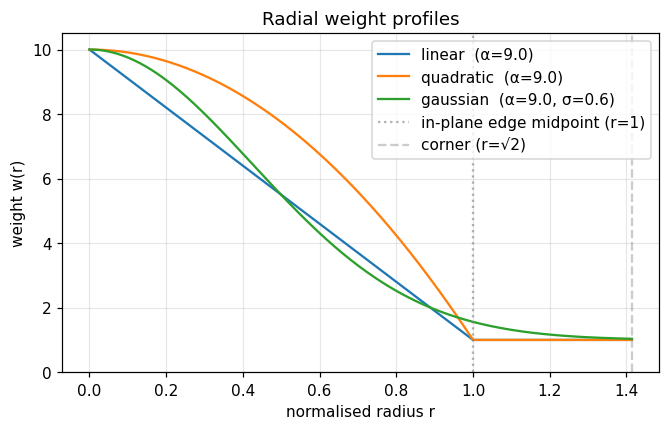

In [3]:
r = np.linspace(0.0, np.sqrt(2), 400)

def w_linear(r, alpha):
    return 1.0 + alpha * np.clip(1.0 - r, 0.0, None)

def w_quadratic(r, alpha):
    return 1.0 + alpha * np.clip(1.0 - r ** 2, 0.0, None)

def w_gaussian(r, alpha, sigma):
    return 1.0 + alpha * np.exp(-(r / sigma) ** 2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r, w_linear(r, ALPHA), label=f'linear  (α={ALPHA})')
ax.plot(r, w_quadratic(r, ALPHA), label=f'quadratic  (α={ALPHA})')
ax.plot(r, w_gaussian(r, ALPHA, GAUSSIAN_SIGMA),
        label=f'gaussian  (α={ALPHA}, σ={GAUSSIAN_SIGMA})')
ax.axvline(1.0, color='gray', ls=':', alpha=0.6, label='in-plane edge midpoint (r=1)')
ax.axvline(np.sqrt(2), color='gray', ls='--', alpha=0.4, label='corner (r=√2)')
ax.set_xlabel('normalised radius r')
ax.set_ylabel('weight w(r)')
ax.set_title('Radial weight profiles')
ax.set_ylim(0, 1 + ALPHA + 0.5)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 2D weight maps (one axial slice)

Each map is `(D, H) = (128, 128)` and is repeated identically across all 64 W slices.

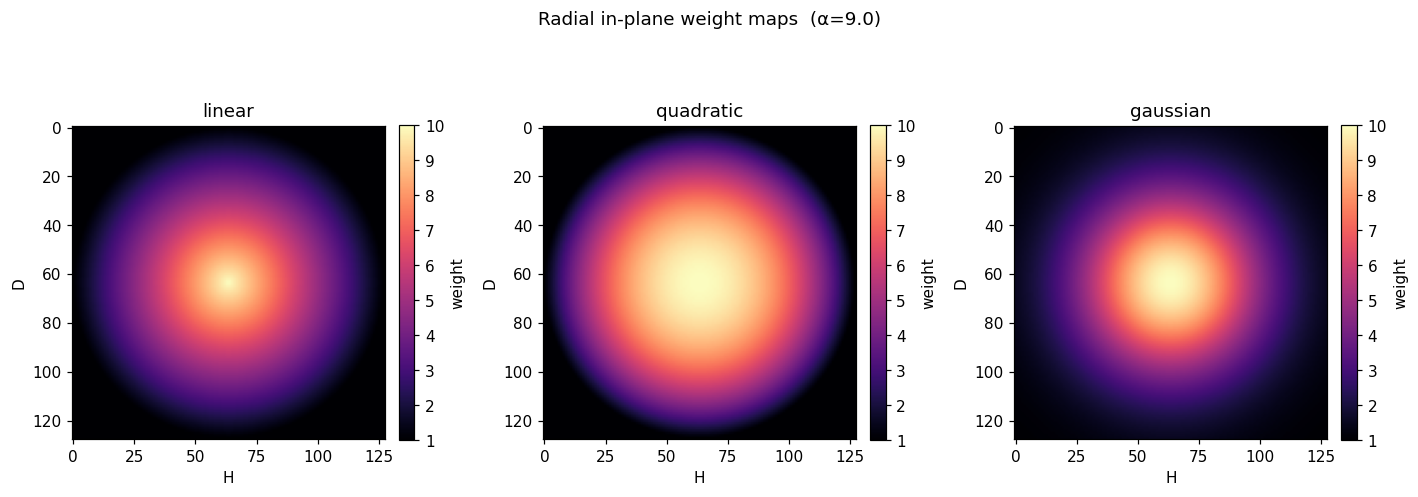

In [4]:
weight_maps = {
    p: radial_inplane_weight_map(
        SHAPE,
        alpha=ALPHA,
        profile=p,
        sigma=GAUSSIAN_SIGMA,
        slice_axis=-1,
    )[0, 0, :, :, 0].numpy()  # take one axial slice; all W slices are identical
    for p in PROFILES
}

vmax = 1.0 + ALPHA
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, p in zip(axes, PROFILES):
    im = ax.imshow(weight_maps[p], vmin=1.0, vmax=vmax, cmap='magma')
    ax.set_title(p)
    ax.set_xlabel('H')
    ax.set_ylabel('D')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='weight')
plt.suptitle(f'Radial in-plane weight maps  (α={ALPHA})', y=1.02)
plt.tight_layout()
plt.show()

## Overlay on real data

Pull one center-time magnitude frame + the precomputed correction tissue mask for a single patient from the downsampled training data, then show the weight map overlaid on a mid-slice.

In [5]:
PATIENT_DATA_ROOT = Path('/home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data')
PATIENT_ID = 'Achelney'
DOWNSAMPLED_FOLDER = 'downsampled_full_fov_128x128x64'
FRAME = 10  # any timepoint; just for visualization

patient_root = PATIENT_DATA_ROOT / PATIENT_ID / 'nifti' / DOWNSAMPLED_FOLDER
mag_path = patient_root / '4d_flow_mag' / f'4d_flow_mag_{PATIENT_ID}_frame_{FRAME:02d}.nii.gz'
tissue_mask_path = patient_root / f'correction_tissue_mask_{PATIENT_ID}.nii.gz'

mag = nib.load(str(mag_path)).get_fdata().astype(np.float32)
tissue_mask = nib.load(str(tissue_mask_path)).get_fdata().astype(np.float32)

print('mag shape:        ', mag.shape, ' min/max:', mag.min(), mag.max())
print('tissue mask shape:', tissue_mask.shape, ' unique:', np.unique(tissue_mask)[:5])

assert mag.shape == SHAPE, f'expected {SHAPE}, got {mag.shape}'

mag shape:         (128, 128, 64)  min/max: 0.0 5821.0
tissue mask shape: (128, 128, 64)  unique: [0. 1.]


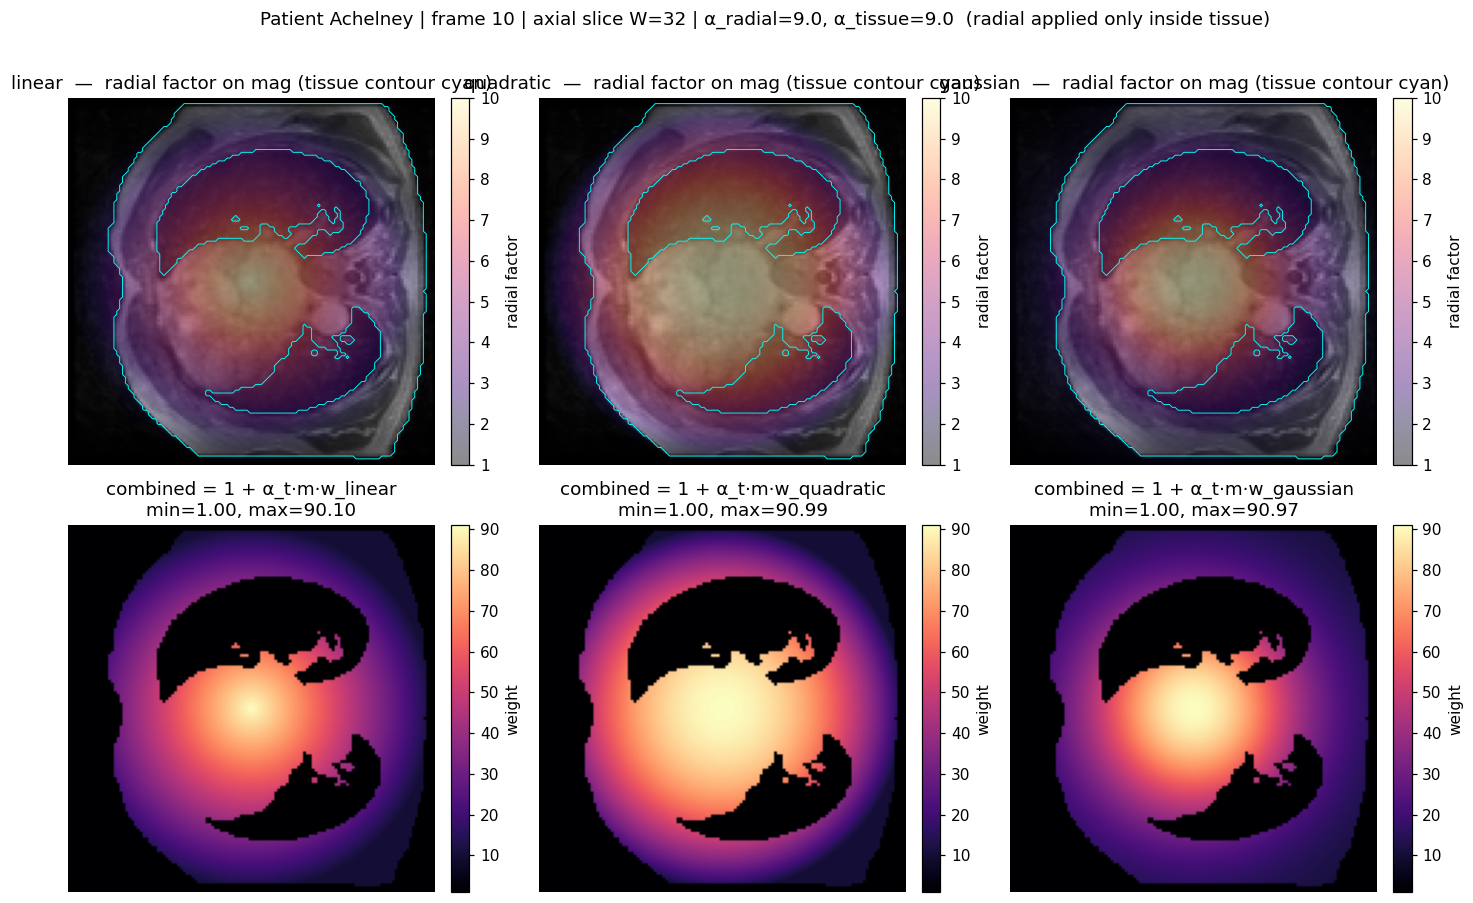

In [6]:
def combine(tissue, radial_factor):
    """w = 1 + alpha_tissue * tissue * radial_factor.

    Air (tissue=0) stays at 1; tissue voxels are upweighted by the tissue
    factor, multiplied by the radial factor (so no radial leak into air).
    `radial_factor` is the full (1 + alpha_r * f(r)) map.
    """
    return 1.0 + TISSUE_ALPHA * tissue * radial_factor


slice_idx = SHAPE[2] // 2  # mid-slice along W (slice axis)
mag_slice = mag[:, :, slice_idx]
tissue_slice = tissue_mask[:, :, slice_idx]

combined_vmax = 1.0 + TISSUE_ALPHA * (1.0 + ALPHA)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for col, p in enumerate(PROFILES):
    w2d = weight_maps[p]

    ax = axes[0, col]
    ax.imshow(mag_slice, cmap='gray')
    im = ax.imshow(w2d, cmap='magma', alpha=0.45, vmin=1.0, vmax=1.0 + ALPHA)
    ax.contour(tissue_slice, levels=[0.5], colors='cyan', linewidths=0.6)
    ax.set_title(f'{p}  —  radial factor on mag (tissue contour cyan)')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='radial factor')

    combined = combine(tissue_slice, w2d)
    ax = axes[1, col]
    im2 = ax.imshow(combined, cmap='magma', vmin=1.0, vmax=combined_vmax)
    ax.set_title(
        f'combined = 1 + α_t·m·w_{p}\n'
        f'min={combined.min():.2f}, max={combined.max():.2f}'
    )
    ax.axis('off')
    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='weight')

plt.suptitle(
    f'Patient {PATIENT_ID} | frame {FRAME} | axial slice W={slice_idx} | '
    f'α_radial={ALPHA}, α_tissue={TISSUE_ALPHA}  (radial applied only inside tissue)',
    y=1.02,
)
plt.tight_layout()
plt.show()

## Quick sanity numbers

For each profile, what fraction of the in-plane area gets `>= 2x` upweight, and what's the mean weight over (a) the whole slice and (b) the tissue mask region?

In [7]:
tissue_bool = tissue_mask.astype(bool)
tissue_inplane_frac = tissue_bool.any(axis=2).mean()
print(f'tissue mask occupies ~{tissue_inplane_frac:.1%} of the in-plane area (any-z projection)\n')

print('Full combined weight = 1 + alpha_tissue * tissue * radial_factor\n')
hdr = '{:>10s}  mean(tissue)  peak(tissue)  mean(air)  peak(air)'
print(hdr.format('profile'))
print('-' * len(hdr.format('profile')))
for p in PROFILES:
    w2d = weight_maps[p]                                # in-plane radial factor (1..1+ALPHA)
    w3d = np.broadcast_to(w2d[..., None], SHAPE).astype(np.float32)
    combined = 1.0 + TISSUE_ALPHA * tissue_mask * w3d   # full per-voxel weight
    in_tissue = combined[tissue_bool]
    in_air    = combined[~tissue_bool]
    print(f'{p:>10s}  '
          f'{in_tissue.mean():>12.2f}  '
          f'{in_tissue.max():>12.2f}  '
          f'{in_air.mean():>9.2f}  '
          f'{in_air.max():>9.2f}')

tissue mask occupies ~81.7% of the in-plane area (any-z projection)

Full combined weight = 1 + alpha_tissue * tissue * radial_factor

   profile  mean(tissue)  peak(tissue)  mean(air)  peak(air)
------------------------------------------------------------
    linear         35.62         90.10       1.00       1.00
 quadratic         48.10         90.99       1.00       1.00
  gaussian         36.21         90.97       1.00       1.00


## Slice stack: every 4th W-slice through the volume

Pick one profile and look at the combined weight (`1 + α_t·m·w_radial`) overlaid on the mag for every 4th axial slice. The radial component is identical on every slice (constant along W); what changes slice-to-slice is the tissue mask, so this shows where the upweight actually lands as you move through the body.

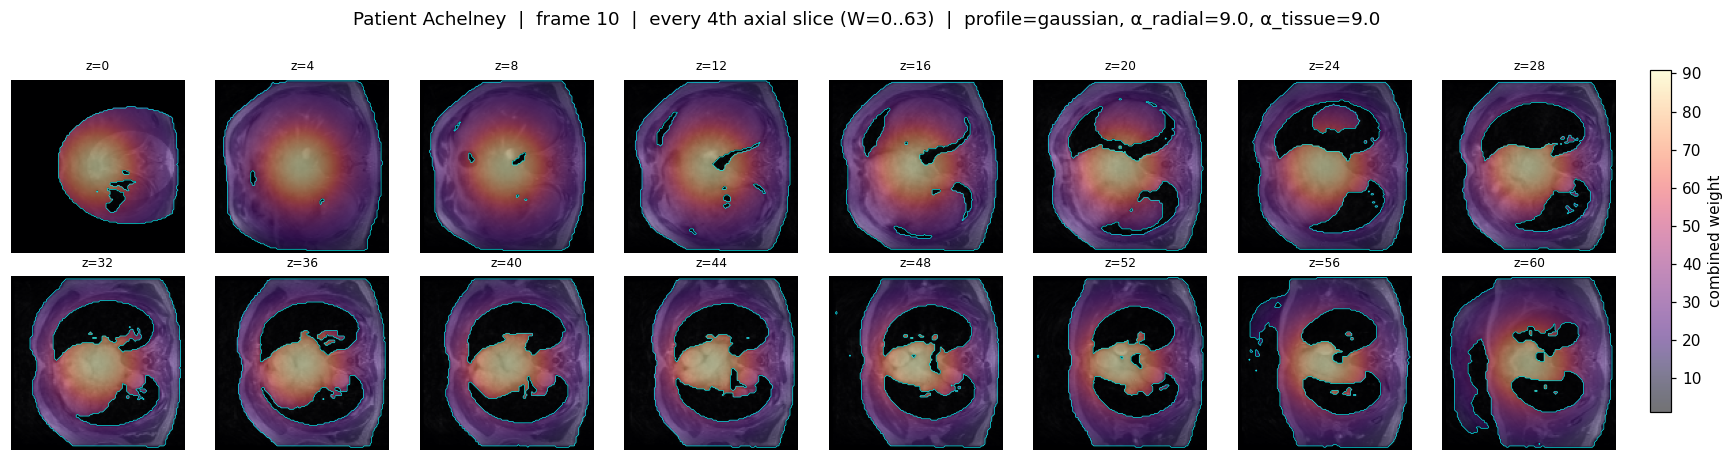

In [8]:
STACK_PROFILE = 'gaussian'  # 'linear' | 'quadratic' | 'gaussian'
STACK_STEP = 4

w_radial_2d = weight_maps[STACK_PROFILE]          # (D, H), constant along W
n_slices = SHAPE[2]
slice_indices = list(range(0, n_slices, STACK_STEP))
n = len(slice_indices)
ncols = 8
nrows = int(np.ceil(n / ncols))

combined_vmax = 1.0 + TISSUE_ALPHA * (1.0 + ALPHA)

fig, axes = plt.subplots(nrows, ncols, figsize=(2.0 * ncols, 2.05 * nrows))
axes_flat = np.atleast_1d(axes).ravel()
last_im = None
for ax, z in zip(axes_flat, slice_indices):
    mag_z = mag[:, :, z]
    tissue_z = tissue_mask[:, :, z]
    combined_z = 1.0 + TISSUE_ALPHA * tissue_z * w_radial_2d
    ax.imshow(mag_z, cmap='gray')
    last_im = ax.imshow(combined_z, cmap='magma', alpha=0.55,
                        vmin=1.0, vmax=combined_vmax)
    if tissue_z.any():
        ax.contour(tissue_z, levels=[0.5], colors='cyan', linewidths=0.4)
    ax.set_title(f'z={z}', fontsize=8)
    ax.axis('off')

for ax in axes_flat[n:]:
    ax.axis('off')

fig.suptitle(
    f'Patient {PATIENT_ID}  |  frame {FRAME}  |  every {STACK_STEP}th axial slice '
    f'(W=0..{n_slices - 1})  |  profile={STACK_PROFILE}, '
    f'α_radial={ALPHA}, α_tissue={TISSUE_ALPHA}',
    y=1.01,
)
fig.tight_layout()
fig.subplots_adjust(right=0.93)
cbar_ax = fig.add_axes([0.945, 0.12, 0.012, 0.76])
fig.colorbar(last_im, cax=cbar_ax, label='combined weight')
plt.show()

## Optional: sweep `ALPHA` for the profile you like

Set `PROFILE_CHOICE` and look at how the weight pattern changes with alpha.

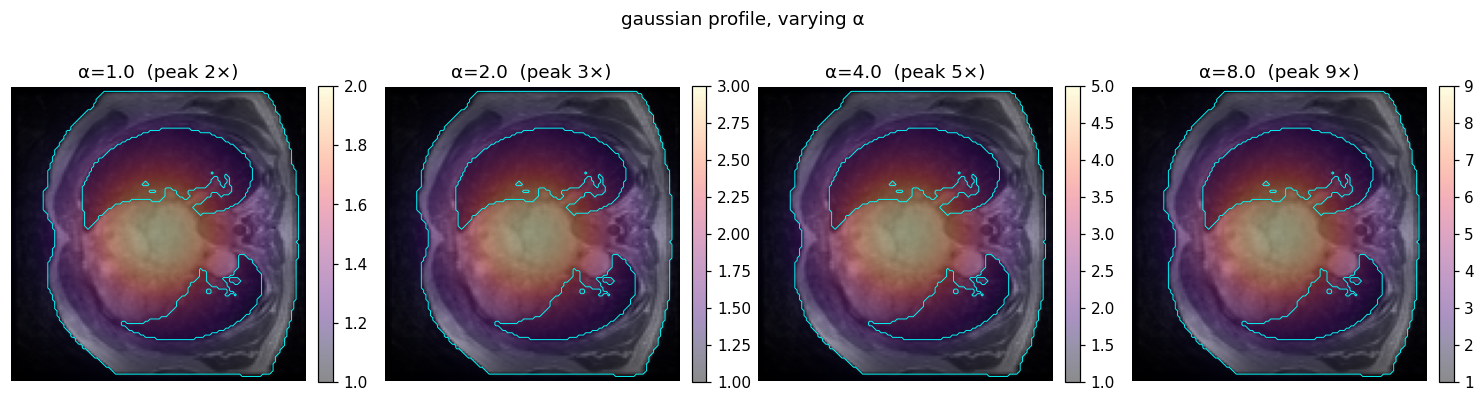

In [9]:
PROFILE_CHOICE = 'gaussian'
ALPHAS = [1.0, 2.0, 4.0, 8.0]

fig, axes = plt.subplots(1, len(ALPHAS), figsize=(3.4 * len(ALPHAS), 3.6))
for ax, a in zip(axes, ALPHAS):
    w2d = radial_inplane_weight_map(
        SHAPE, alpha=a, profile=PROFILE_CHOICE,
        sigma=GAUSSIAN_SIGMA, slice_axis=-1,
    )[0, 0, :, :, 0].numpy()
    ax.imshow(mag_slice, cmap='gray')
    im = ax.imshow(w2d, cmap='magma', alpha=0.45, vmin=1.0, vmax=1.0 + a)
    ax.contour(tissue_slice, levels=[0.5], colors='cyan', linewidths=0.6)
    ax.set_title(f'α={a}  (peak {1+a:.0f}×)')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle(f'{PROFILE_CHOICE} profile, varying α', y=1.02)
plt.tight_layout()
plt.show()

## Sweep `sigma` for the gaussian profile

`sigma` is in units of normalised radius (`r=1` is the closest edge midpoint, `r=√2` is a corner). It controls the width of the central bump only; `alpha` still sets the peak height.

- Small σ (≤ 0.2): very tight bump, only the centermost voxels get any extra weight.
- Medium σ (0.3-0.5): tightly centered on the great vessels but smoothly falls off across the mediastinum.
- Large σ (≥ 0.7): the bump bleeds all the way to the edges, so the contrast between center and edge shrinks.

Three side-by-side views below: the 1D profiles, the 2D radial-factor maps, and the combined `1 + α_t·m·radial` overlay on a mid-slice for each σ.

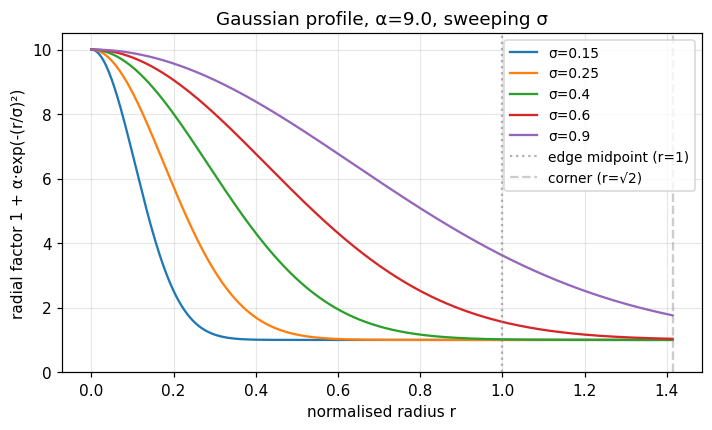

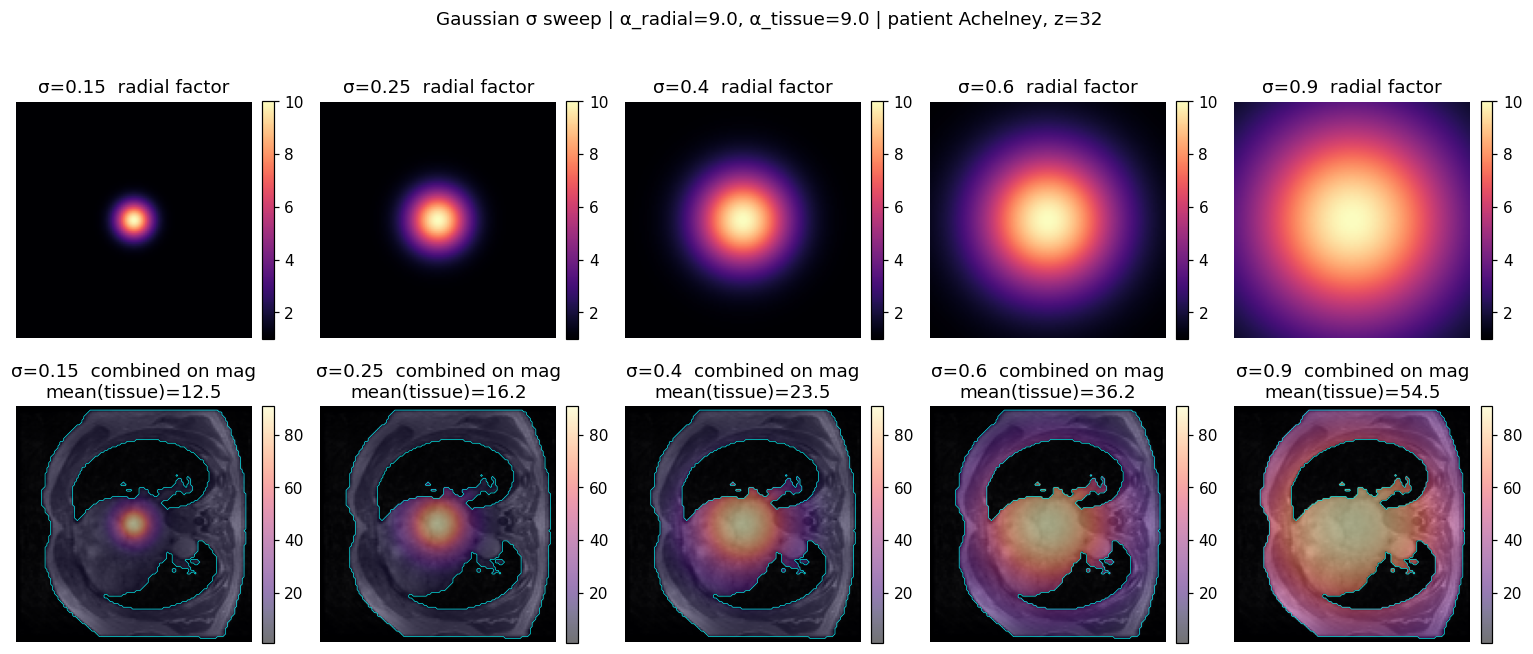

In [10]:
SIGMAS = [0.15, 0.25, 0.4, 0.6, 0.9]

# --- 1D profiles ---
fig, ax = plt.subplots(figsize=(7.5, 4))
r1d = np.linspace(0.0, np.sqrt(2), 400)
for s in SIGMAS:
    ax.plot(r1d, w_gaussian(r1d, ALPHA, s), label=f'σ={s}')
ax.axvline(1.0, color='gray', ls=':', alpha=0.6, label='edge midpoint (r=1)')
ax.axvline(np.sqrt(2), color='gray', ls='--', alpha=0.4, label='corner (r=√2)')
ax.set_xlabel('normalised radius r')
ax.set_ylabel('radial factor 1 + α·exp(-(r/σ)²)')
ax.set_title(f'Gaussian profile, α={ALPHA}, sweeping σ')
ax.set_ylim(0, 1 + ALPHA + 0.5)
ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.show()

# --- 2D radial-factor maps + combined overlay on mid-slice ---
fig, axes = plt.subplots(2, len(SIGMAS), figsize=(2.8 * len(SIGMAS), 6))
combined_vmax = 1.0 + TISSUE_ALPHA * (1.0 + ALPHA)
for col, s in enumerate(SIGMAS):
    w_map_full = radial_inplane_weight_map(
        SHAPE, alpha=ALPHA, profile='gaussian', sigma=s, slice_axis=-1,
    )[0, 0, :, :, 0].numpy()

    ax = axes[0, col]
    im = ax.imshow(w_map_full, cmap='magma', vmin=1.0, vmax=1.0 + ALPHA)
    ax.set_title(f'σ={s}  radial factor')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    combined = combine(tissue_slice, w_map_full)
    ax = axes[1, col]
    im2 = ax.imshow(mag_slice, cmap='gray')
    im2 = ax.imshow(combined, cmap='magma', alpha=0.55,
                    vmin=1.0, vmax=combined_vmax)
    ax.contour(tissue_slice, levels=[0.5], colors='cyan', linewidths=0.4)
    ax.set_title(f'σ={s}  combined on mag\nmean(tissue)={combined[tissue_slice.astype(bool)].mean():.1f}')
    ax.axis('off')
    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f'Gaussian σ sweep | α_radial={ALPHA}, α_tissue={TISSUE_ALPHA} | '
    f'patient {PATIENT_ID}, z={slice_idx}',
    y=1.02,
)
plt.tight_layout()
plt.show()

## Next step

Once you pick a `(profile, alpha)` pair, I'll wire it into `dual_task_trainer.py` so the correction weight map becomes

```python
corr_weight_map = 1.0 + tissue_alpha * tissue_mask * radial_factor   # radial only inside tissue
```

and expose `correction_radial_upweight` + `correction_radial_profile` (+ optional `correction_radial_sigma`) in `unet_dual_head.yaml`.